# 03 - Wave Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_{tt} = c^2 u_{xx}$, $c = 1.0$

**IC:** $u(x,0) = \sin(\pi x)$, $u_t(x,0) = 0$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

**Note:** Wave equation is second-order in time - requires velocity IC.
Oscillatory nature makes it sensitive to sparse data.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    WaveFDM, Benchmark, save_metrics, save_history
)

PDE        = 'wave'
LAYERS     = [2, 64, 64, 64, 64, 64, 1]
EPOCHS     = 10000
PDE_PARAMS = {'c': 1.0}
RESULTS    = '../results/wave/'
FIGURES    = '../figures/wave/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, c=1.0)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

WaveFDM solved in 0.0164s


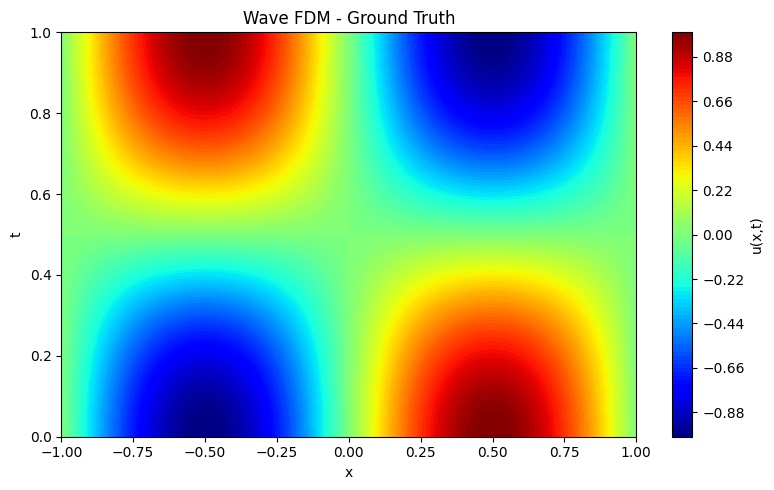

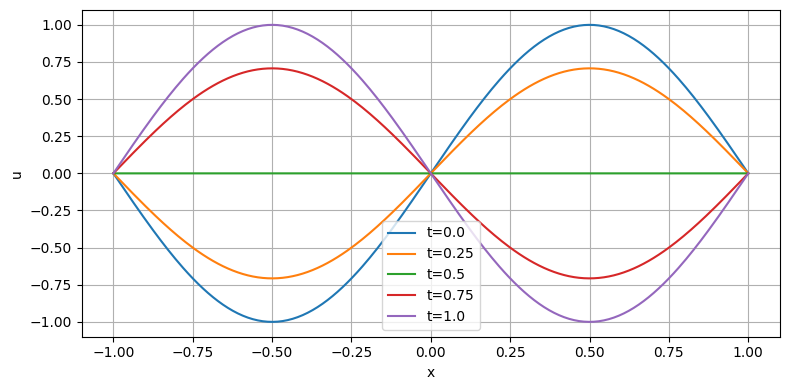

In [2]:
fdm = WaveFDM(nx=256, nt=2000, c=1.0)
fdm.solve()
fdm.plot_solution(title='Wave FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')
print(f'Wave data includes u_ic_dt: {"u_ic_dt" in data_clean_dense}')

Data ready
Wave data includes u_ic_dt: True


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 0.621628 | IC: 0.448284 | BC: 0.150495 | PDE: 0.004570


Epoch  1000 | Total: 0.041895 | IC: 0.017228 | BC: 0.023336 | PDE: 0.000266


Epoch  2000 | Total: 0.013857 | IC: 0.003413 | BC: 0.007965 | PDE: 0.000496


Epoch  3000 | Total: 0.001691 | IC: 0.000373 | BC: 0.000865 | PDE: 0.000091


...

Epoch  6000 | Total: 0.000193 | IC: 0.000045 | BC: 0.000042 | PDE: 0.000021


Epoch  7000 | Total: 0.000145 | IC: 0.000029 | BC: 0.000034 | PDE: 0.000016


Epoch  8000 | Total: 0.000154 | IC: 0.000028 | BC: 0.000033 | PDE: 0.000019


Epoch  9000 | Total: 0.000239 | IC: 0.000038 | BC: 0.000039 | PDE: 0.000033



Training complete in 227.75s


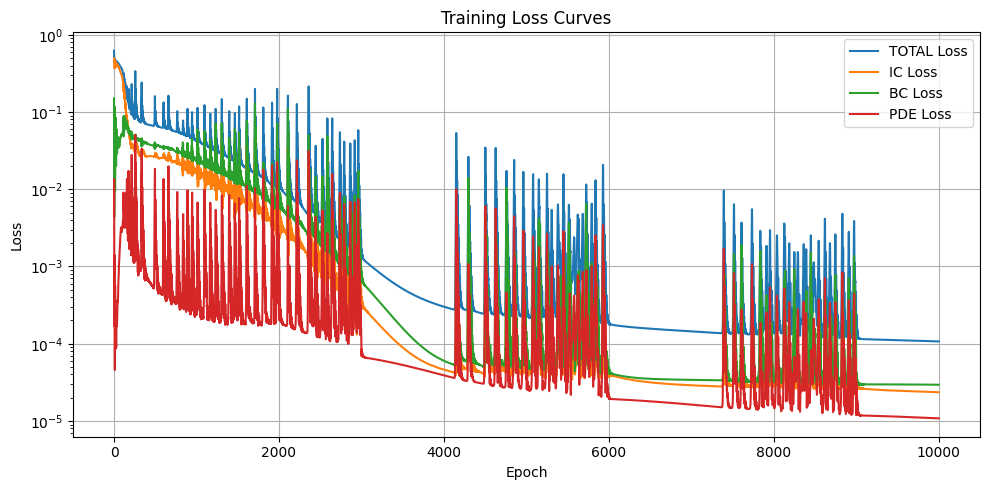

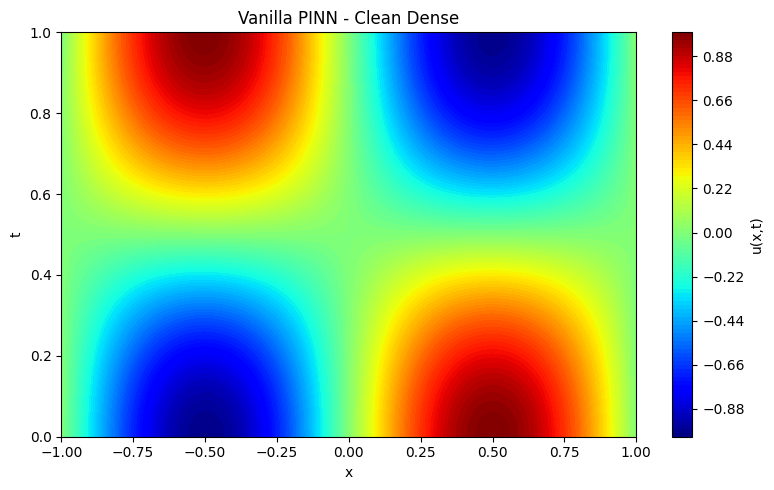

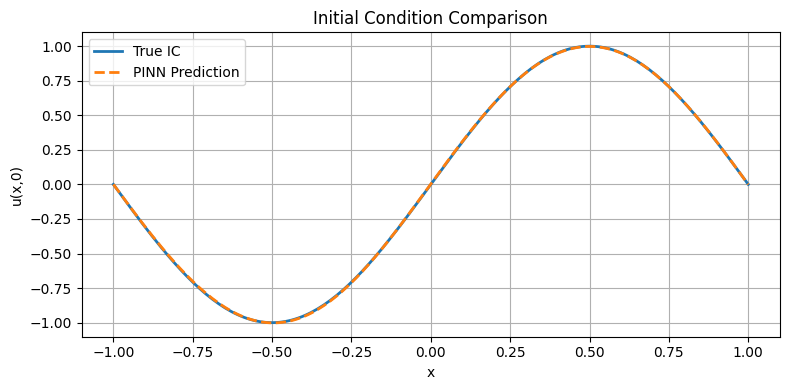

Saved: ../results/wave/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000)
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

Epoch     0 | Total: 1.686174 | IC: 1.063364 | BC: 0.427994 | PDE: 0.038963


Epoch  1000 | Total: 0.097433 | IC: 0.034865 | BC: 0.055421 | PDE: 0.001429


Epoch  2000 | Total: 0.059781 | IC: 0.031528 | BC: 0.027529 | PDE: 0.000145


Epoch  3000 | Total: 0.040615 | IC: 0.021706 | BC: 0.018330 | PDE: 0.000116


Epoch  4000 | Total: 0.036933 | IC: 0.020548 | BC: 0.016156 | PDE: 0.000046


...

Epoch  6000 | Total: 0.042637 | IC: 0.020777 | BC: 0.016317 | PDE: 0.001109


Epoch  7000 | Total: 0.036327 | IC: 0.020379 | BC: 0.015860 | PDE: 0.000017


Epoch  8000 | Total: 0.037179 | IC: 0.020431 | BC: 0.015986 | PDE: 0.000152


Epoch  9000 | Total: 0.036240 | IC: 0.020351 | BC: 0.015823 | PDE: 0.000013



Training complete in 186.25s


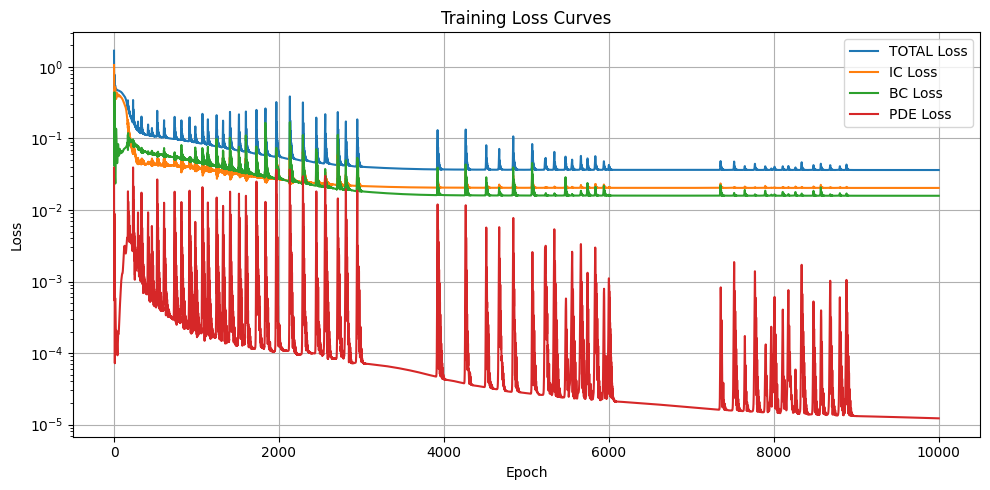

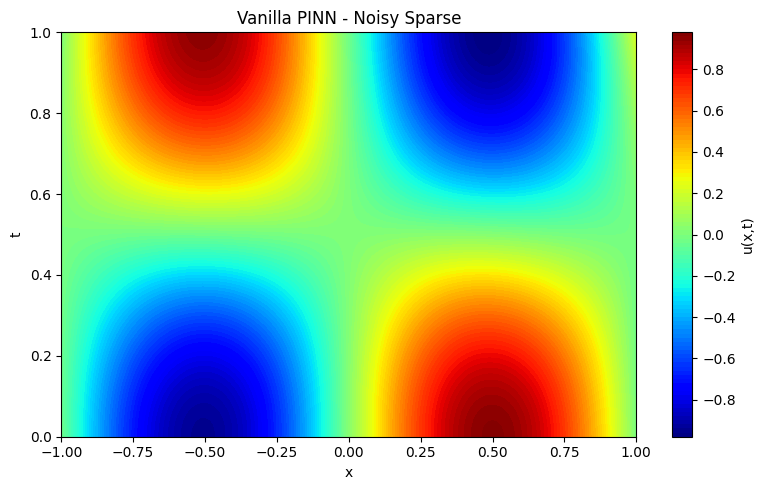

Saved: ../results/wave/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000)
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

Epoch     0 | Stage 1/4 | Total: 0.529719 | IC: 0.524826 | BC: 0.002406 | PDE: 0.000497 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.066136 | IC: 0.020910 | BC: 0.010927 | PDE: 0.000198 | λ=(1.63,2.76,10.00)


Epoch  2000 | Stage 1/4 | Total: 0.084829 | IC: 0.004314 | BC: 0.040561 | PDE: 0.000394 | λ=(7.92,1.15,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.026474 | IC: 0.000653 | BC: 0.014492 | PDE: 0.000329 | λ=(8.42,1.22,10.00)


Epoch  4000 | Stage 2/4 | Total: 0.007934 | IC: 0.000135 | BC: 0.003935 | PDE: 0.000202 | λ=(8.83,1.20,10.00)


...

Epoch  6000 | Stage 3/4 | Total: 0.004409 | IC: 0.000091 | BC: 0.001786 | PDE: 0.001051 | λ=(0.10,1.83,1.08)


Epoch  7000 | Stage 3/4 | Total: 0.004998 | IC: 0.002249 | BC: 0.000554 | PDE: 0.000808 | λ=(1.87,0.46,0.67)


Epoch  8000 | Stage 4/4 | Total: 0.132279 | IC: 0.003403 | BC: 0.050658 | PDE: 0.004960 | λ=(0.17,2.57,0.25)


Epoch  9000 | Stage 4/4 | Total: 0.097849 | IC: 0.037409 | BC: 0.001732 | PDE: 0.004470 | λ=(2.57,0.12,0.31)



AC-PINN training complete in 232.29s


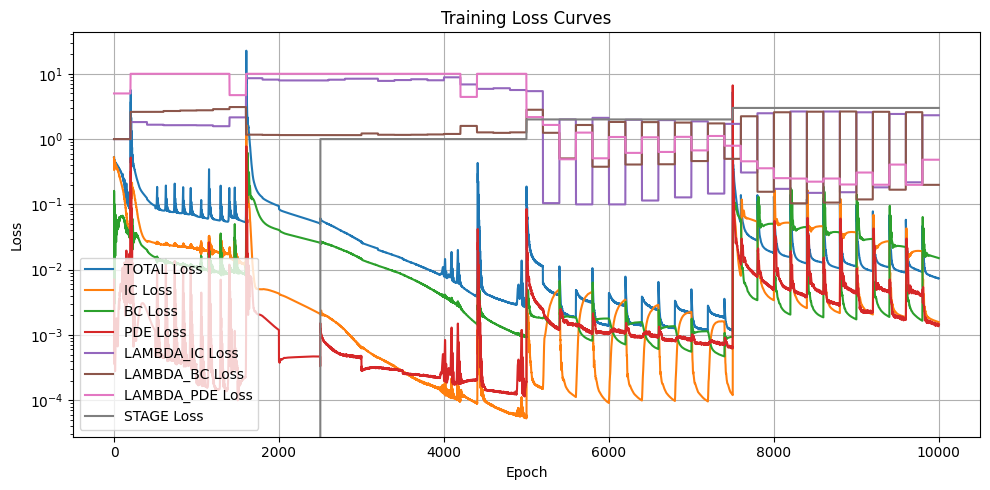

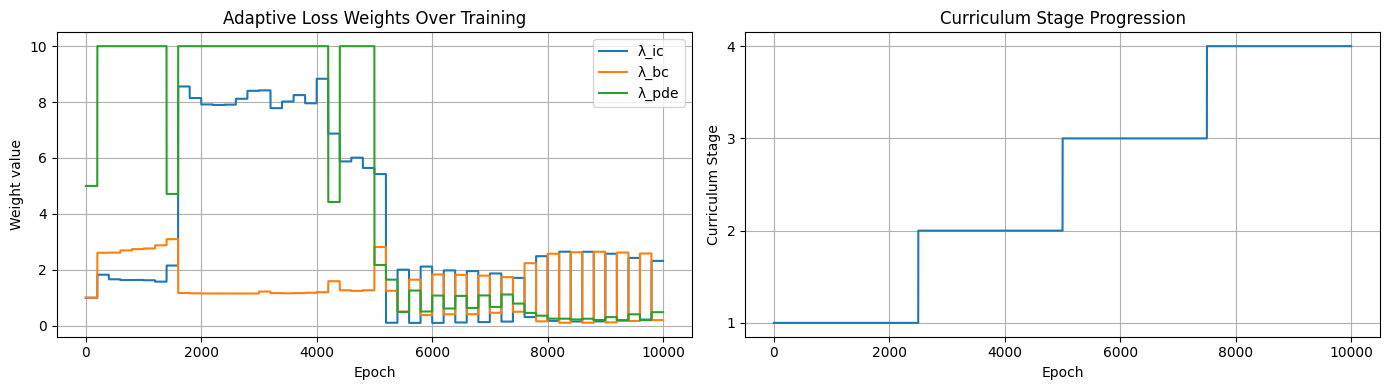

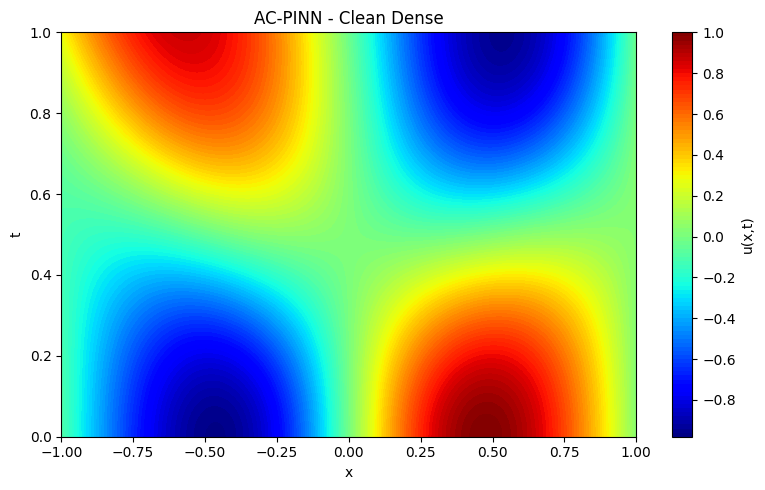

Saved: ../results/wave/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000)
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

Epoch     0 | Stage 1/4 | Total: 0.562856 | IC: 0.539348 | BC: 0.022927 | PDE: 0.000116 | λ=(1.00,1.00,5.00)


Epoch  1000 | Stage 1/4 | Total: 0.116940 | IC: 0.024577 | BC: 0.020831 | PDE: 0.001044 | λ=(2.77,1.89,9.23)


Epoch  2000 | Stage 1/4 | Total: 0.094548 | IC: 0.021275 | BC: 0.017293 | PDE: 0.000414 | λ=(1.59,3.28,10.00)


Epoch  3000 | Stage 2/4 | Total: 0.247034 | IC: 0.024057 | BC: 0.017871 | PDE: 0.003007 | λ=(2.60,10.00,1.93)


Epoch  4000 | Stage 2/4 | Total: 0.124478 | IC: 0.020181 | BC: 0.015852 | PDE: 0.001428 | λ=(3.67,2.95,2.57)


...

Epoch  6000 | Stage 3/4 | Total: 0.055642 | IC: 0.021515 | BC: 0.019294 | PDE: 0.006490 | λ=(1.36,1.22,0.41)


Epoch  7000 | Stage 3/4 | Total: 0.049653 | IC: 0.019918 | BC: 0.015462 | PDE: 0.004002 | λ=(1.52,1.18,0.30)


Epoch  8000 | Stage 4/4 | Total: 0.065948 | IC: 0.023948 | BC: 0.024456 | PDE: 0.014633 | λ=(1.14,1.16,0.70)


Epoch  9000 | Stage 4/4 | Total: 0.051972 | IC: 0.020235 | BC: 0.015474 | PDE: 0.001972 | λ=(1.61,1.23,0.16)



AC-PINN training complete in 197.83s


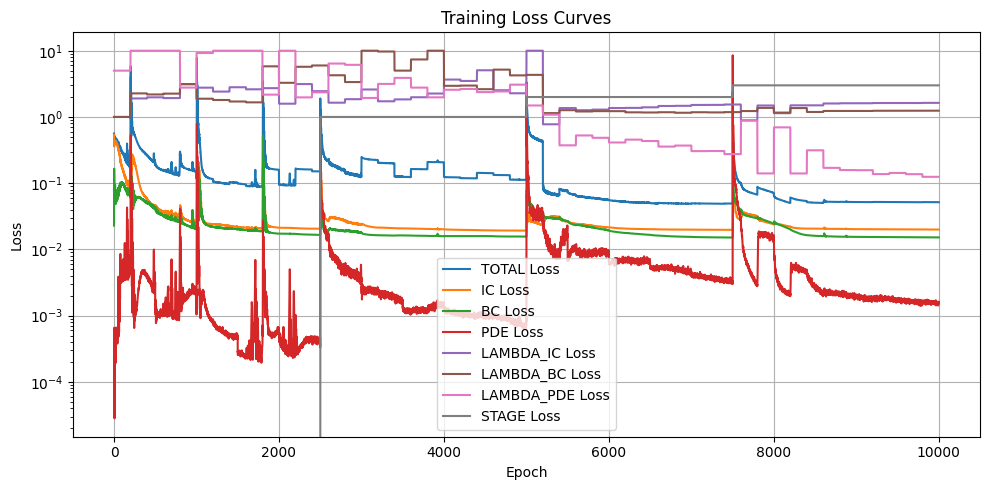

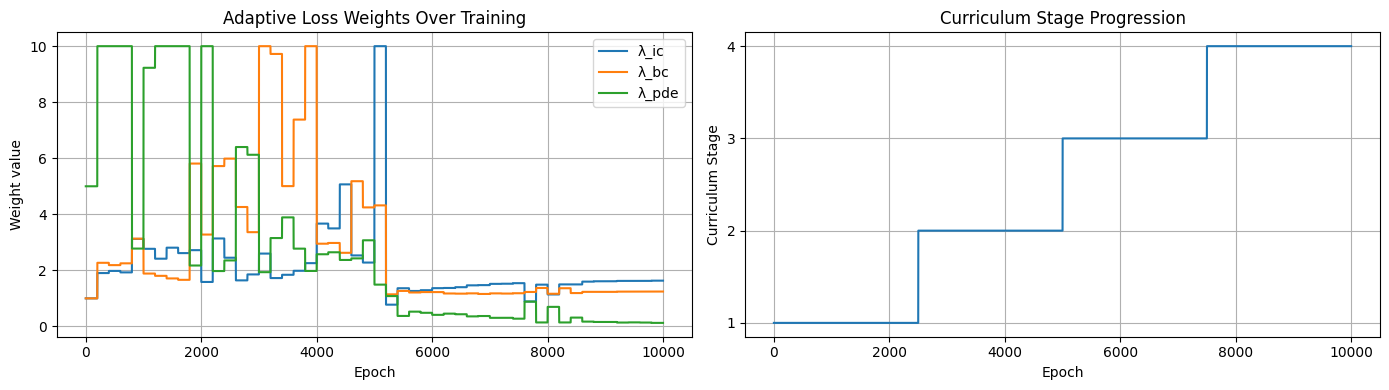

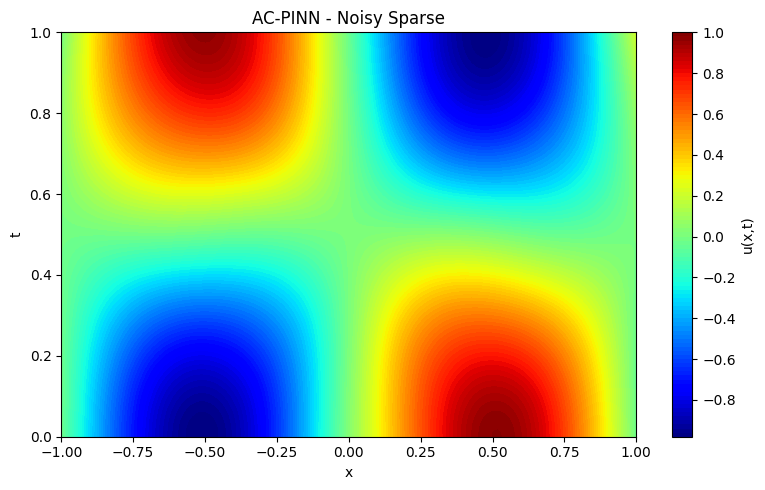

Saved: ../results/wave/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000)
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.016873   0.021872   0.006586   0.008415
  Vanilla (noisy)             0.056975   0.220689   0.021344   0.028414
  AC-PINN (clean)             0.125707   0.281940   0.044367   0.062692
  AC-PINN (noisy)             0.067789   0.201475   0.026018   0.033807


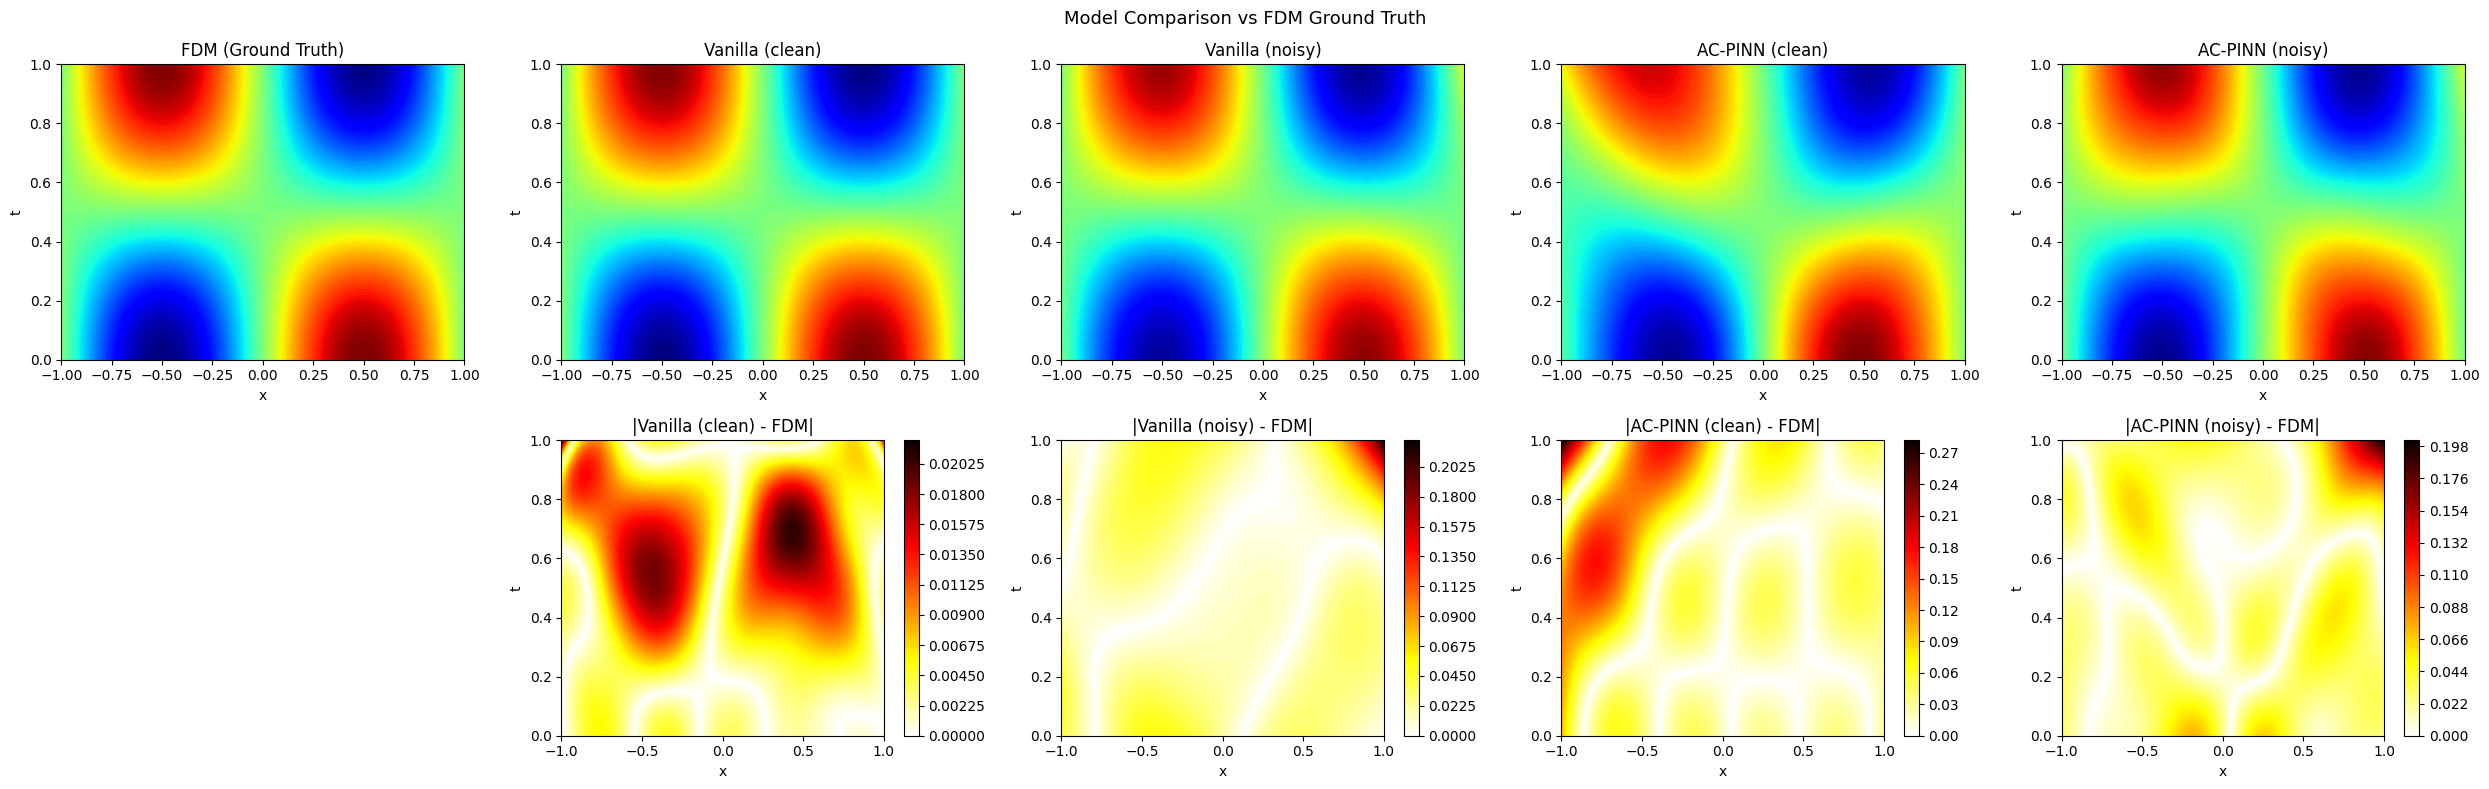

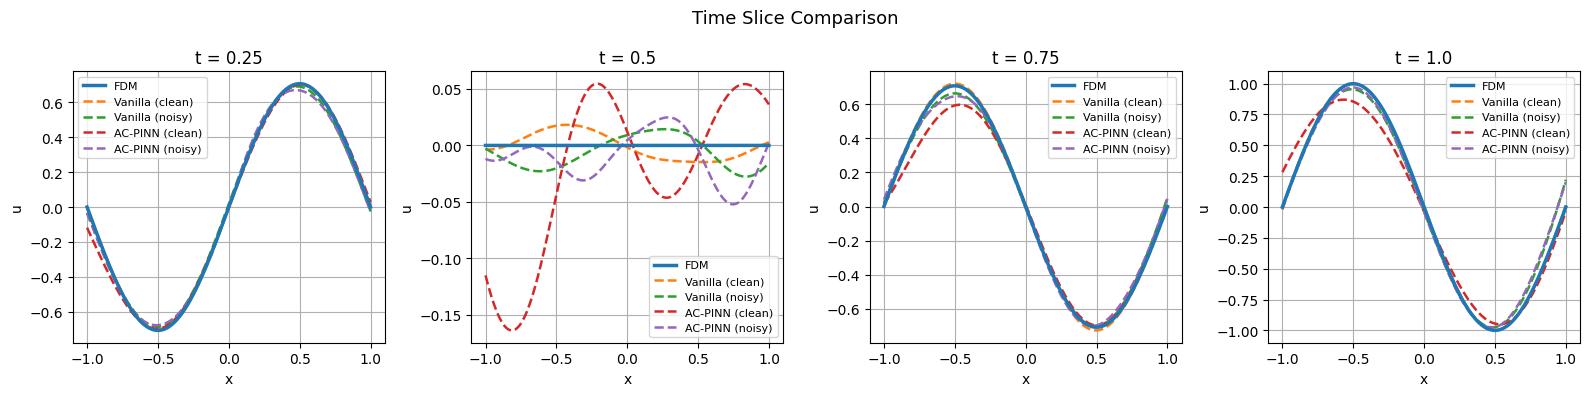

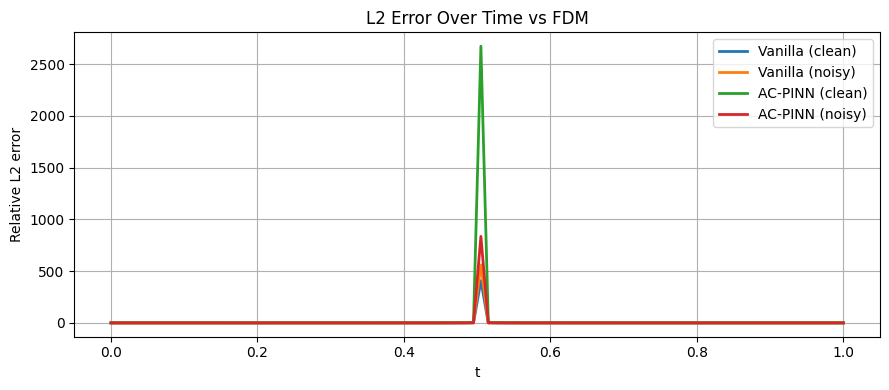

Saved: ../results/wave/benchmark_metrics.npy
Wave experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Wave experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
Epoch     0 | Total: 0.779603 | IC: 0.296944 | BC: 0.418687 | PDE: 0.012794


Epoch  2500 | Total: 0.014515 | IC: 0.007601 | BC: 0.006429 | PDE: 0.000097



Training complete in 94.38s
Epoch     0 | Stage 1/4 | Total: 0.573849 | IC: 0.547062 | BC: 0.025646 | PDE: 0.000228 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.051768 | IC: 0.017218 | BC: 0.006117 | PDE: 0.000292 | λ=(1.35,4.20,10.00)



AC-PINN training complete in 101.06s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.053783   0.070311   0.020516   0.026823
  AC-PINN ε=0.05              0.064206   0.119372   0.026144   0.032020

--- ε=0.1 ---
Epoch     0 | Total: 0.569394 | IC: 0.533517 | BC: 0.023985 | PDE: 0.002378


...


AC-PINN training complete in 101.11s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.066171   0.081553   0.027276   0.033001
  AC-PINN ε=0.1               0.089579   0.123424   0.036680   0.044675

--- ε=0.2 ---
Epoch     0 | Total: 1.314062 | IC: 1.045806 | BC: 0.231119 | PDE: 0.007427


Epoch  2500 | Total: 0.152857 | IC: 0.075923 | BC: 0.076099 | PDE: 0.000167



Training complete in 94.85s
Epoch     0 | Stage 1/4 | Total: 0.887004 | IC: 0.734814 | BC: 0.148246 | PDE: 0.000789 | λ=(1.00,1.00,5.00)


Epoch  2500 | Stage 2/4 | Total: 0.440151 | IC: 0.108834 | BC: 0.078503 | PDE: 0.000282 | λ=(1.42,3.61,10.00)



AC-PINN training complete in 102.54s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.157274   0.195329   0.064768   0.078435
  AC-PINN ε=0.2               0.174447   0.291541   0.071627   0.086999
Saved: ../results/wave/noise_study_metrics.npy
